# Preliminary results for section 2.3

## package installation

In [1]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


## reading files and generate results

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

fileName = "./data/ModelsResults.xlsx"  # If it's in the current directory
sheetName = "allResults"
limit = 32 #20
df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "BLEU"]).iloc[:limit, :]
df

,Model,Compression,BLEU
0,pythia-70M,Original,42.000000
1,pythia-70M,8-bit,41.390000
2,pythia-70M,4-bit,39.210000
3,pythia-70M,dyn,35.989180
4,pythia-160M,Original,42.490000
5,pythia-160M,8-bit,42.310000
6,pythia-160M,4-bit,40.600000
7,pythia-160M,dyn,38.069959
8,pythia-410M,Original,43.510000
9,pythia-410M,8-bit,43.610000


/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_66732/1078908751.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["Compression"] = df["Compression"].replace({


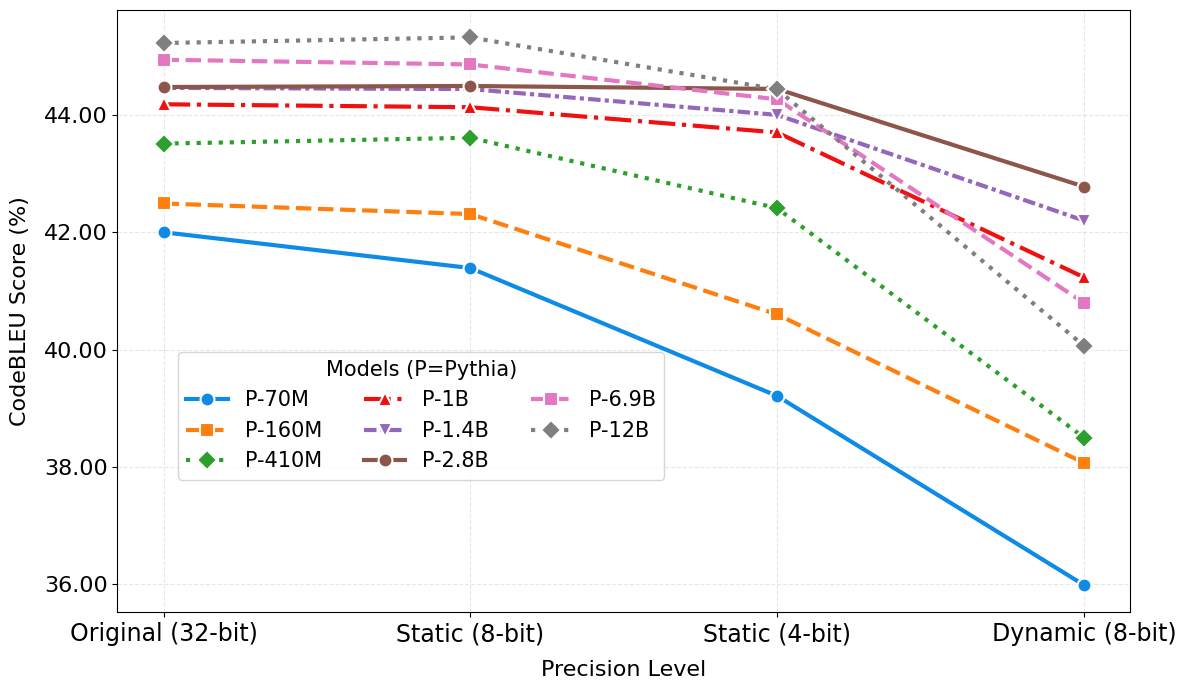

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

df = pd.read_excel(fileName, sheet_name=sheetName, skiprows=2, usecols=["Model", "Compression", "BLEU"]).iloc[:limit, :]
# Define styles with line patterns
model_styles = {
        "pythia-70M": {"color": "#0d8be5", "marker": "o", "linestyle": "-", "dash": None, "label": "P-70M"},
        "pythia-160M": {"color": "#ff7f0e", "marker": "s", "linestyle": "--", "dash": (5, 5), "label": "P-160M"},
        "pythia-410M": {"color": "#2ca02c", "marker": "D", "linestyle": ":", "dash": (1, 1), "label": "P-410M"},
        "pythia-1B": {"color": "#ef1010", "marker": "^", "linestyle": "-.", "dash": (3, 5, 1, 5), "label": "P-1B"},
        "pythia-1.4B": {"color": "#9467bd", "marker": "v", "linestyle": (0, (3, 1, 1, 1)), "dash": None, "label": "P-1.4B"},
        "pythia-2.8B": {"color": "#8c564b", "marker": "o", "linestyle": "-", "dash": None, "label": "P-2.8B"},
        "pythia-6.9B": {"color": "#e377c2", "marker": "s", "linestyle": "--", "dash": (5, 5), "label": "P-6.9B"},
        "pythia-12B": {"color": "#7f7f7f", "marker": "D", "linestyle": ":", "dash": (1, 1), "label": "P-12B"}
    }
# Prepare data
compression_order = ["Original", "8-bit", "4-bit", "dyn"]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# Rename x-axis labels
df["Compression"] = df["Compression"].replace({
    "Original": "Original (32-bit)", 
    "8-bit": "Static (8-bit)", 
    "4-bit": "Static (4-bit)", 
    "dyn": "Dynamic (8-bit)"
})

# Create figure
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Plot each model with custom styling
for model, style in model_styles.items():
    if model in df["Model"].unique():
        model_df = df[df["Model"] == model]
        ax.plot(
            model_df["Compression"].cat.codes,  # Use numeric codes for positioning
            model_df["BLEU"],
            label=model.replace("pythia-", "P-"),
            color=style["color"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=3,
            markersize=10,
            markeredgecolor='white',
            markeredgewidth=1.5
        )

# Configure x-axis
ax.set_xticks(range(len(compression_order)))
ax.set_xticklabels([
    "Original (32-bit)", 
    "Static (8-bit)", 
    "Static (4-bit)", 
    "Dynamic (8-bit)"
], fontsize=17, rotation=0, ha='center')

# Add legend
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.3, .45),
    ncol=3,
    fontsize=15,
    frameon=True,
    title='Models (P=Pythia)',
    title_fontsize=15
)

# Axis labels and formatting
plt.ylabel("CodeBLEU Score (%)", fontsize=16, labelpad=10)
plt.xlabel("Precision Level", fontsize=16, labelpad=10)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.3)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

# Final adjustments
plt.tight_layout()
plt.savefig("./output/staticVSdynamic.pdf", dpi=350, bbox_inches="tight")
plt.show()